# Numerical Simulation Laboratory (NSL) 
## Numerical exercises 4

In [1]:
import scipy
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.gridspec as gridspec

from scipy.stats import norm
from scipy.optimize import curve_fit
from scipy.special import erf
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from numpy import exp
from numpy.lib.scimath import log, sqrt

plt.style.use('default')
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['legend.fontsize'] = 10
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6

color=plt.cm.inferno(0.5)
color2=plt.cm.inferno(0.2)

### Exercise 04.1

In Statistical Mechanics the Maxwell–Boltzmann distribution (<a href="https://en.wikipedia.org/wiki/Maxwell%E2%80%93Boltzmann_distribution" target="_blank">Link Wikipedia</a>) is a probability distribution used for describing particle speeds in idealized gases. However, rarefied gases at ordinary temperatures behave very nearly like an ideal gas and the Maxwell–Boltzmann speed distribution is an excellent approximation for such gases. For a 3D system its formula is:
$$p(v,T) = \left( \frac{m}{2\pi k_B T} \right)^{3/2} 4\pi v^2 e^{-\frac{m v^2}{2 k_B T}}$$

By using LJ reduced units (Lenght: $\sigma$; Energy: $\epsilon$; Mass: the mass, $m$, of the particles; Temperature: $\epsilon/k_B$; velocity: $\sqrt{\epsilon/m}$) its form becomes:
$$p(v^*,T^*) = \frac{1}{(2\pi T^*)^{3/2}} 4\pi (v^*)^2 e^{-\frac{(v^*)^2}{2 T^*}}$$

The NSL_SIMULATOR code already computes the total (internal) energy per particle, $E/N$, the potential energy per particle, $U/N$, the kinetic energy per particle, $K/N$, the temperature, $T$, and the pressure, $P$.

Include the calculation of the Maxwell–Boltzmann distribution, $p(v^*,T^*)$, inside your Molecular Dynamics code by using data blocking to obtain single block averages, progressive average values and progressive uncertainties for $p(v^*,T^*)$.

Remember that, the Maxwell–Boltzmann distribution, $p(v^*,T^*)$, can be approximately computed as a **normalized histogram** on an appropriate interval $\left[ 0, v_{max}\right]$ and chosing the number of bins into which you want to divide this interval.


### Implementation

#### Implementazione della Maxwell-Boltzmann Distribution nel File system.cpp
Nel file system.cpp, sono state implementate funzioni per calcolare la distribuzione di Maxwell-Boltzmann ( $p(v, T)$ ) utilizzando un approccio di Molecular Dynamics con unità ridotte di Lennard-Jones. La distribuzione viene calcolata come un istogramma normalizzato delle velocità delle particelle, con l'uso del metodo di data blocking per ottenere medie e incertezze progressive.

#### Strumenti Principali per la Misura delle Velocità

1. Calcolo delle velocità delle particelle:

- Le velocità delle particelle vengono inizializzate nella funzione initialize_velocities() e aggiornate durante la simulazione tramite l'algoritmo di Verlet nella funzione Verlet().
- Le velocità sono salvate in vettori tridimensionali ($( v_x, v_y, v_z )$) per ciascuna particella.

2. Distribuzione delle velocità:

- La distribuzione di Maxwell-Boltzmann ( $p(v, T)$ ) viene calcolata nella funzione measure() utilizzando un istogramma.
- La velocità ( $v^*$ ) di ciascuna particella è calcolata come: [ $v^* = \sqrt{v_x^2 + v_y^2 + v_z^2}$ ]
- Le velocità vengono accumulate in un istogramma con un numero di bin specificato nel file properties.dat.

3. Normalizzazione dell'istogramma:

- L'istogramma viene normalizzato per rappresentare una distribuzione di probabilità continua:  $$p(v, T) = \frac{1}{(2\pi T)^{3/2}} 4\pi (v)^2 e^{-\frac{(v)^2}{2 T}} \, .$$
- La normalizzazione è effettuata dividendo i conteggi per il numero totale di particelle e la larghezza del bin.

4. Salvataggio dei dati:

- I risultati dell'istogramma normalizzato vengono salvati nel file POFV.dat, che contiene:
    - Colonna 1: Numero del blocco.
    - Colonna 2: Velocità ( $v^*$ ).
    - Colonna 3: Valore medio ( $p(v, T)$ ) per il blocco.
    - Colonna 4: Media progressiva.
    - Colonna 5: Errore progressivo.

#### Files di Input
1. File input.dat:
Contiene i parametri principali della simulazione:
- TEMP: Temperatura iniziale del sistema ( $T^* = 1.1$ ).
- NPART: Numero di particelle ( $N = 108$ ).
- RHO: Densità ridotta ( $\rho^* = 0.8$ ).
- NBLOCKS: Numero di blocchi per il data blocking ( $20$ ).
- NSTEPS: Numero di passi per blocco ( $2000$ ).
Questi parametri influenzano direttamente la dinamica del sistema e la raccolta dei dati.

2. File properties.dat:
Specifica le proprietà da misurare durante la simulazione. Per calcolare la distribuzione di Maxwell-Boltzmann è necessario includere la proprietà POFV, che noi fissiamo a $30$ (numero di bin per l'istogramma della velocità).
La funzione initialize_properties() legge questo file e configura i parametri necessari per il calcolo della distribuzione.

#### Data Blocking
Il metodo di data blocking è utilizzato per calcolare medie e incertezze progressive delle proprietà misurate, inclusa la distribuzione ( $p(v, T)$ ). Con i parametri specificati:

NBLOCKS = 20: La simulazione è suddivisa in 20 blocchi.
NSTEPS = 2000: Ogni blocco contiene 2000 passi temporali.

1. Misure per blocco:

Durante ogni blocco, vengono calcolate le velocità delle particelle e aggiornato l'istogramma ( $p(v, T)$ ).
Le medie per blocco vengono accumulate in un vettore _block_av.

2. Medie progressive:

Dopo ogni blocco, vengono calcolate le medie progressive e le incertezze utilizzando la funzione averages():  $$\text{Errore} = \sqrt{\frac{\langle X^2 \rangle - \langle X \rangle^2}{n}} \, .$$ 
I risultati vengono salvati nei file di output.

3. Vantaggi del data blocking:

Permette di stimare l'incertezza statistica delle misure.
Garantisce che le medie siano calcolate su dati indipendenti, riducendo la correlazione tra i campioni.

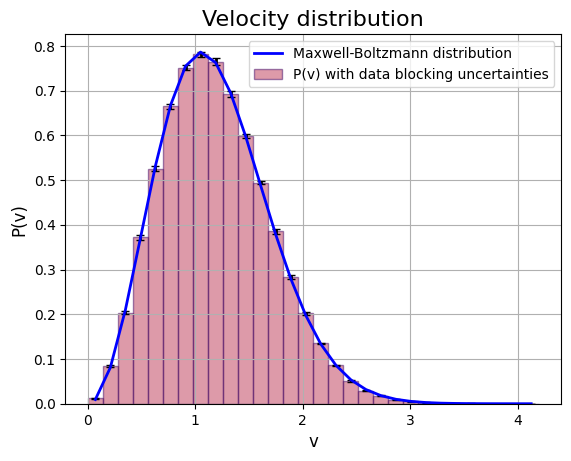

In [2]:
# Legge il file ignorando la riga di intestazione
data = np.loadtxt("ex04.1/OUTPUT/POFV.dat", skiprows=1)

# Estrae le colonne dal file
blocks = data[:, 0]
velocities = data[:, 1]
actual_pofv = data[:, 2]
ave_pofv = data[:, 3]
errors = data[:, 4]

# Seleziona l'ultimo blocco
last_block = int(blocks.max())
mask = blocks == last_block
last_velocities = velocities[mask]
last_ave_pofv = ave_pofv[mask]
last_errors = errors[mask]

# Larghezza del bin ricavata dai centri
dv = last_velocities[1] - last_velocities[0]

# Normalizzazione corretta per una distribuzione continua
norm = np.sum(last_ave_pofv * dv)
last_ave_pofv /= norm
last_errors /= norm

# Legge la temperatura dall'ultimo blocco del file temperature.dat
temp_data = np.loadtxt("ex04.1/OUTPUT/temperature.dat", comments="#")
temp_blocks = temp_data[:, 0]
temp_ave = temp_data[:, 2]

# Trova la temperatura media dell'ultimo blocco
T = temp_ave[temp_blocks == last_block][0]

# Calcola la distribuzione teorica di Maxwell-Boltzmann
maxwell_boltzmann = (4 * np.pi * last_velocities**2 * np.exp(-last_velocities**2 / (2 * T))) / ((2 * np.pi * T)**(3/2))

# Plot dei valori medi con barre d'errore
plt.bar(last_velocities, last_ave_pofv, width=dv, yerr=last_errors, capsize=3, alpha=0.5, label='P(v) with data blocking uncertainties', color=color, edgecolor=color2)
plt.plot(last_velocities, maxwell_boltzmann, label="Maxwell-Boltzmann distribution", color='b')

plt.xlabel("v")
plt.ylabel("P(v)")
plt.title("Velocity distribution")
plt.legend()
plt.grid(True)
plt.show()

### Exercise 04.2

By means of your upgraded code, perform MD simulations via a Lennard-Jones model ( e.g. Argon parameters: $\sigma = 0.34$ nm, $\epsilon/k_B = 120$ K, $m=39.948$ amu) in the following conditions:
- gas phase: $\rho^\star = 0.05$, $T^\star \sim  2.0$ (cut-off radius: $r_c = 5.0$)

starting from a **very low entropic** initial configuration:
1. initial **particle positions**: fcc crystal occupying half of the simulation box in each dimension
2. initial **velocity distribution**: $p_\delta(v^*,T^*) = \delta\left( v^* - v_{T^*}\right)$ where $v_{T^*}$ is suitably connected to $T^*$. For example, this condition could be obtained by imposing that every particle has an initial velocity $\pm v_{T^*}$ for **only one** of its velocity components: $v_x$, $v_y$, $v_z$.

The goal is to show that, by evolving such initial condition via a Molecular Dynamics simulation, the velocity distribution tends to approximate the Maxwell–Boltzmann distribution.

- **Produce some pictures that show this convergence**
- The evolution of the system moves towards the increasing of entropy (more homeogeneous configuration of particles)? What would you find by changing the direction of time? Comment on these aspects in your jupyter-notebook

**Note that** the MD simulation will conserve the total energy; thus the kinetic energy and the temperature are not constant of motion ... the comparison should be done with $p(v^*,T^*_{\rm eff})$ where $T^*_{\rm eff}$ is the effective temperature obtained once the system has been equilibrated.

### Implementation
Il file system.cpp implementa i metodi necessari per eseguire simulazioni di Dinamica Molecolare (MD) utilizzando il modello di Lennard-Jones, con l'obiettivo di studiare l'evoluzione di un sistema inizialmente in una configurazione a bassa entropia verso una distribuzione di velocità che approssima la distribuzione di Maxwell-Boltzmann.

#### Condizioni Iniziali

1. **Posizioni iniziali delle particelle:**

Le particelle sono inizializzate in una configurazione fcc (face-centered cubic) che occupa metà della scatola di simulazione in ciascuna dimensione. Questo garantisce una configurazione iniziale a bassa entropia, con le particelle disposte in modo ordinato.

2. **Distribuzione iniziale delle velocità:**

- Le velocità iniziali delle particelle sono impostate in modo che ogni particella abbia una velocità ( $\pm v_{T^*}$ ) lungo una sola componente ($( v_x, v_y, v_z )$).
- La velocità ($ v_{T} $) è calcolata in base alla temperatura ridotta ( $T$ ) utilizzando il teorema di equipartizione: [ $v_{T} = \sqrt{3 T}$ ] (questo è implementato nella funzione initialize_velocities()).

3. **Condizioni di input:**

I parametri di input specificati in input.dat e properties.dat configurano la simulazione:
- input.dat:
    - TEMP = 2.0: Temperatura iniziale ridotta ( $T^*$ ).
    - RHO = 0.05: Densità ridotta ( $\rho^*$ ).
    - R_CUT = 5.0: Raggio di cut-off per il potenziale di Lennard-Jones.
    - NBLOCKS = 30, NSTEPS = 2000: Parametri per il data blocking.
- properties.dat:
    - Include la proprietà POFV 30, che abilita il calcolo della distribuzione di velocità ( $p(v, T)$ ) con 30 bin.

#### Evoluzione del Sistema

1. **Integrazione delle equazioni del moto:**

La simulazione utilizza l'algoritmo di Verlet per integrare le equazioni del moto delle particelle.
La funzione Verlet() calcola le nuove posizioni e velocità delle particelle, tenendo conto delle forze calcolate tramite il potenziale di Lennard-Jones:  $$F(r) = 48 \left( \frac{1}{r^{13}} - \frac{1}{2r^7} \right) \, .$$

Le velocità sono aggiornate in modo consistente con il metodo di Verlet.

2. **Condizioni al contorno periodiche:**

La funzione pbc() applica le condizioni al contorno periodiche per mantenere le particelle all'interno della scatola di simulazione.

3. **Calcolo delle proprietà termodinamiche:**

La funzione measure() calcola le proprietà del sistema, tra cui:
- Energia potenziale per particella ( $U/N$ ).
- Energia cinetica per particella ( $K/N$ ).
- Temperatura ( $T$ ).
- Distribuzione di velocità ( $p(v, T)$ ).

#### Conservazione dell'Energia
La simulazione conserva l'energia totale del sistema, ma la temperatura e l'energia cinetica non sono costanti di moto.
Dopo un periodo di equilibrazione, il sistema raggiunge una temperatura efficace ( $T^*_{\text{eff}}$ ), che viene utilizzata per confrontare la distribuzione simulata con la distribuzione teorica di Maxwell-Boltzmann.
Partendo da una distribuzione iniziale a bassa entropia ($ p_\delta(v, T)$ ), il sistema evolve verso una distribuzione di velocità che approssima ( $p(v, T)$ ).
Questo è un esempio di aumento dell'entropia, poiché il sistema si sposta verso uno stato più omogeneo.

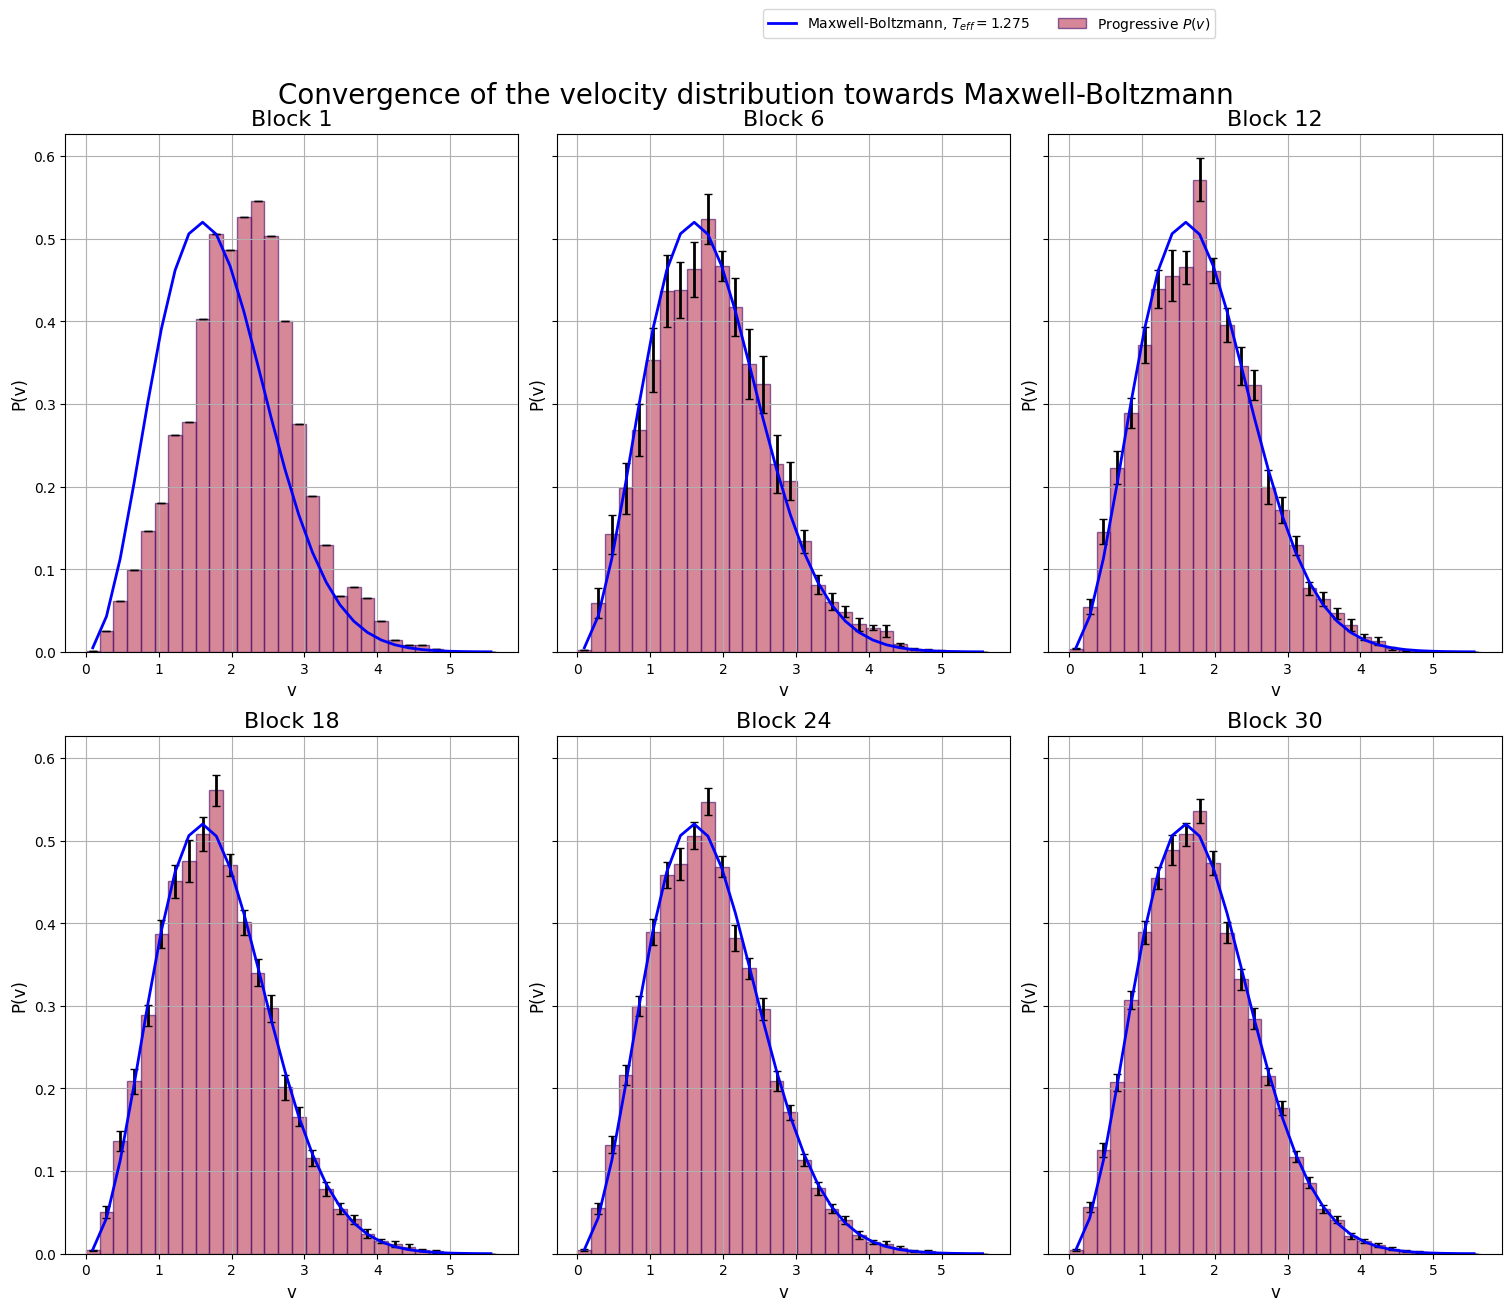

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Caricamento dei dati
data = np.loadtxt("ex04.2/OUTPUT/POFV.dat", skiprows=1)
temp_data = np.loadtxt("ex04.2/OUTPUT/temperature.dat", comments="#")

# Estrazione delle colonne
blocks = data[:, 0]
velocities = data[:, 1]
ave_pofv = data[:, 3]
errors = data[:, 4]

temp_blocks = temp_data[:, 0]
actual_temps = temp_data[:, 1]

# Calcolo della temperatura efficace (T_eff) usando gli ultimi 5 blocchi
last_block = int(temp_blocks.max())
relaxed_blocks = actual_temps[temp_blocks > last_block - 5]
T_eff = np.mean(relaxed_blocks)

# Blocchi selezionati
selected_blocks = [1, 6, 12, 18, 24, 30]

# Creazione della figura con subplot uniformi
fig, axes = plt.subplots(2, 3, figsize=(15, 12), sharey=True, constrained_layout=True)

# Loop sui blocchi selezionati
for i, blk in enumerate(selected_blocks):
    # Filtra i dati per il blocco corrente
    mask = blocks == blk
    block_velocities = velocities[mask]
    block_ave_pofv = ave_pofv[mask]
    block_errors = errors[mask]

    # Calcolo della larghezza del bin
    dv = block_velocities[1] - block_velocities[0]

    # Normalizzazione
    norm = np.sum(block_ave_pofv * dv)
    block_ave_pofv /= norm
    block_errors /= norm

    # Ottieni l'asse corrente
    ax = axes[i // 3, i % 3]

    # Istogramma
    ax.bar(
        block_velocities,
        block_ave_pofv,
        width=dv,
        yerr=block_errors,
        capsize=3,
        alpha=0.6,
        color=color,
        edgecolor=color2,
        label="Progressive $P(v)$"
    )

    # Distribuzione di Maxwell-Boltzmann
    maxwell_boltzmann = (4 * np.pi * block_velocities**2 * np.exp(-block_velocities**2 / (2 * T_eff))) / ((2 * np.pi * T_eff)**(3/2))
    ax.plot(
        block_velocities,
        maxwell_boltzmann,
        label=fr"Maxwell-Boltzmann, $T_{{eff}}={T_eff:.3f}$",
        color="b"
    )

    # Titoli e assi
    ax.set_title(f"Block {blk}")
    ax.set_xlabel("v")
    ax.set_ylabel("P(v)")
    ax.grid(True)

# Una sola legenda globale, fuori dai pannelli
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower left", ncol=2, bbox_to_anchor=(0.5, 1.05))

fig.suptitle("Convergence of the velocity distribution towards Maxwell-Boltzmann", fontsize=20, y=1.02)
#fig.suptitle("Convergence of the velocity distribution towards Maxwell-Boltzmann", y=1.02)

plt.show()

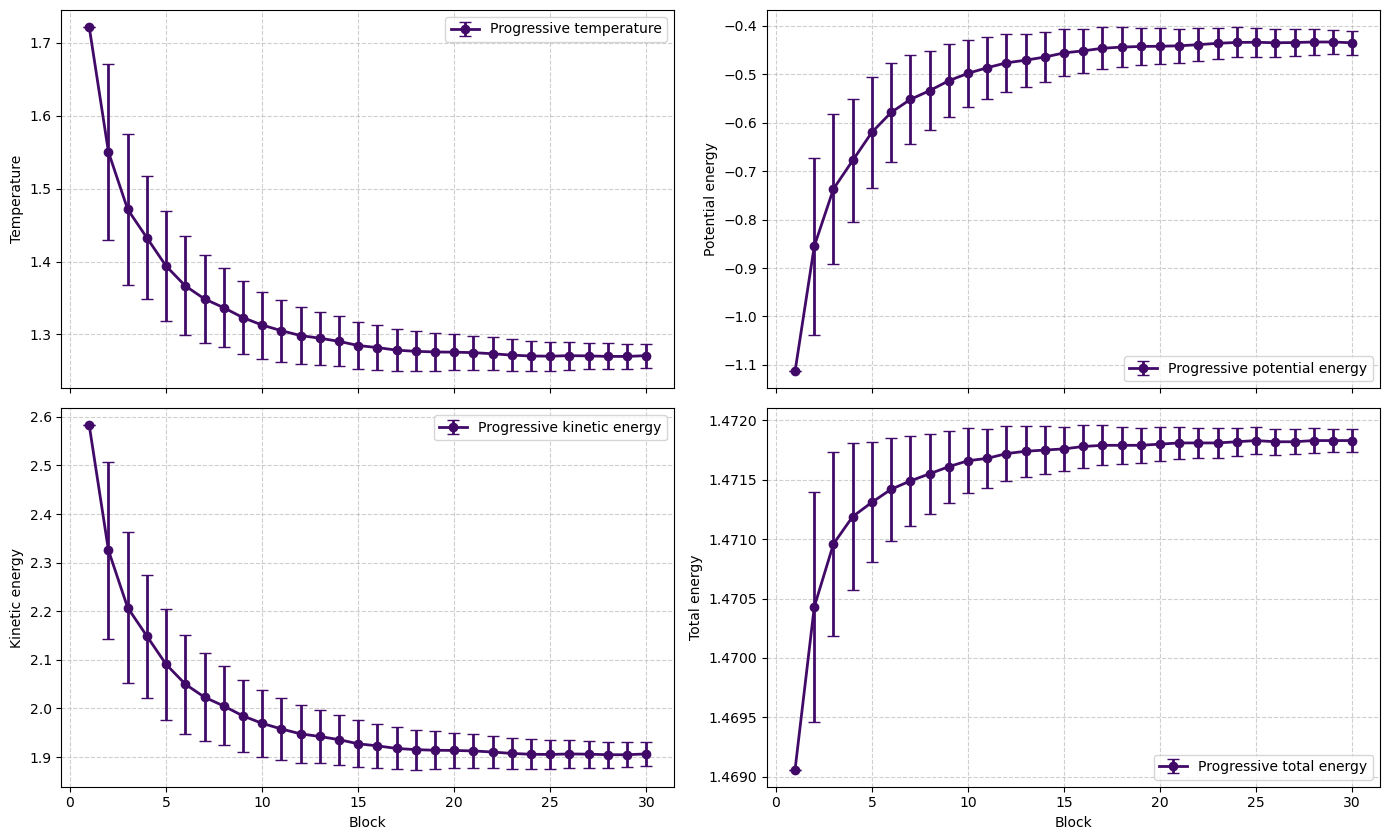

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def plot_all_data(temp_file, pot_file, kin_file, tot_file):
    # Caricamento dei dati
    data_temp = np.loadtxt(temp_file, skiprows=1)
    data_pot = np.loadtxt(pot_file, skiprows=1)
    data_kin = np.loadtxt(kin_file, skiprows=1)
    data_tot = np.loadtxt(tot_file, skiprows=1)
    
    # Estrazione delle colonne
    blocks_temp, t_ave, t_err = data_temp[:, 0], data_temp[:, 2], data_temp[:, 3]
    blocks_pot, pot_ave, pot_err = data_pot[:, 0], data_pot[:, 2], data_pot[:, 3]
    blocks_kin, kin_ave, kin_err = data_kin[:, 0], data_kin[:, 2], data_kin[:, 3]
    blocks_tot, tot_ave, tot_err = data_tot[:, 0], data_tot[:, 2], data_tot[:, 3]
    
    # Creazione dei subplots
    fig, axs = plt.subplots(2, 2, figsize=(14, 8.5))
    axs = axs.flatten()
    
    # Temperatura
    axs[0].errorbar(
        blocks_temp, t_ave, yerr=t_err, fmt="o-", capsize=4, label="Progressive temperature", color=color2
    )
    #axs[0].axhline(1, linestyle='-.', color='red', alpha=0.6, label='Equilibration temperature')
    axs[0].set_ylabel('Temperature', fontsize=10)
    axs[0].legend()
    axs[0].grid(True, alpha=0.6, linestyle='--')
    axs[0].tick_params(axis='x', labelbottom=False)
    
    # Energia potenziale
    axs[1].errorbar(
        blocks_pot, pot_ave, yerr=pot_err, fmt="o-", capsize=4, label="Progressive potential energy", color=color2
    )
    axs[1].set_ylabel('Potential energy', fontsize=10)
    axs[1].legend()
    axs[1].grid(True, alpha=0.6, linestyle='--')
    axs[1].tick_params(axis='x', labelbottom=False)
    
    # Energia cinetica
    axs[2].errorbar(
        blocks_kin, kin_ave, yerr=kin_err, fmt="o-", capsize=4, label="Progressive kinetic energy", color=color2
    )
    axs[2].set_xlabel('Block', fontsize=10)
    axs[2].set_ylabel('Kinetic energy', fontsize=10)
    axs[2].legend()
    axs[2].grid(True, alpha=0.6, linestyle='--')
    
    # Energia totale
    axs[3].errorbar(
        blocks_tot, tot_ave, yerr=tot_err, fmt="o-", capsize=4, label="Progressive total energy", color=color2
    )
    axs[3].set_xlabel('Block', fontsize=10)
    axs[3].set_ylabel('Total energy', fontsize=10)
    axs[3].legend()
    axs[3].grid(True, alpha=0.6, linestyle='--')
    
    # Layout
    plt.tight_layout()
    plt.show()

# Chiamata alla funzione con i file di input
plot_all_data(
    'ex04.2/OUTPUT/temperature.dat',
    'ex04.2/OUTPUT/potential_energy.dat',
    'ex04.2/OUTPUT/kinetic_energy.dat',
    'ex04.2/OUTPUT/total_energy.dat'
)

### Exercise 04.3

Starting from the **final states** of two MD simulations of the system in Exercise 04.2, one with about $5\times 10^3$ time-steps the other with about $5\times 10^4$ time-steps, by changing the direction of time (e.g. by inverting the final velocities, i.e. ... ), try to return back to the very low entropic initial configuration of Exercise 04.2. Is this possible? (for example, one can monitor the behavior of the average **potential energy** and the average **temperature** in **each block** as a function of time going **in both directions**. Show some picture and comment on what you find in your jupyter-notebook.

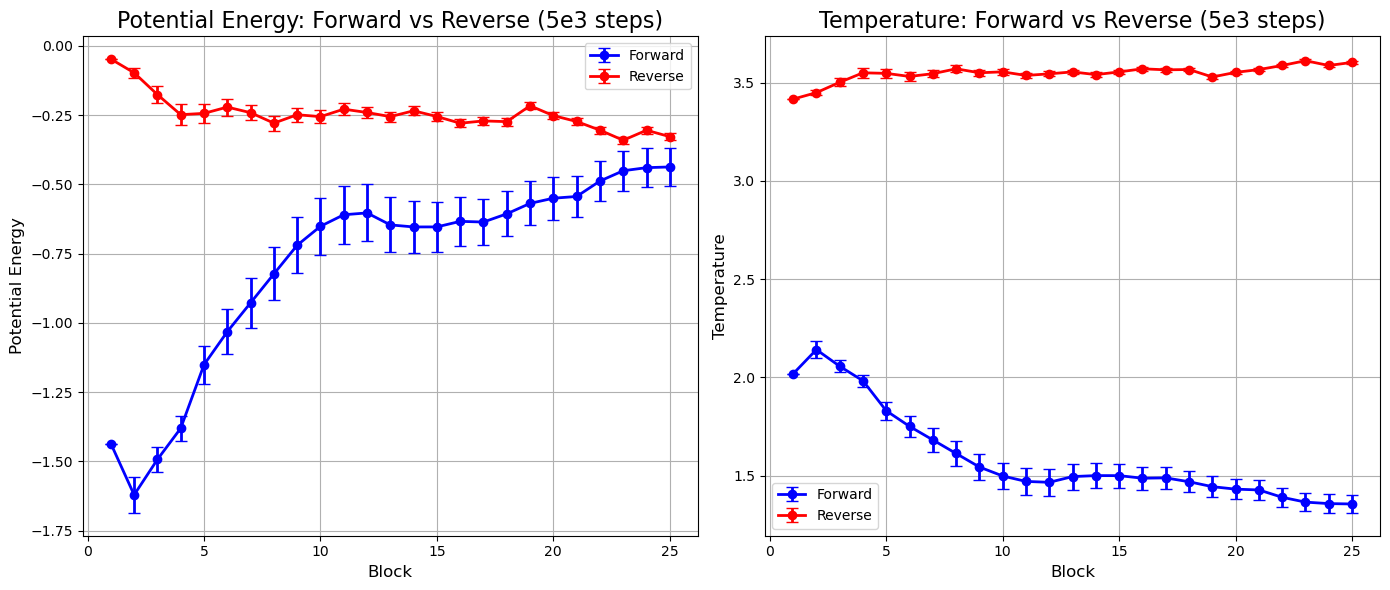

In [ ]:
# Caricamento dei dati per l'energia potenziale
pot_dir_5e3 = np.loadtxt("ex04.3/OUTPUT_dir_5e3/potential_energy.dat", skiprows=1)
pot_rev_5e3 = np.loadtxt("ex04.3/OUTPUT_rev_5e3/potential_energy.dat", skiprows=1)

# Estrazione delle colonne per l'energia potenziale
blocks_dir, pot_ave_dir, pot_err_dir = pot_dir_5e3[:, 0], pot_dir_5e3[:, 1], pot_dir_5e3[:, 3]
blocks_rev, pot_ave_rev, pot_err_rev = pot_rev_5e3[:, 0], pot_rev_5e3[:, 1], pot_rev_5e3[:, 3]

# Caricamento dei dati per la temperatura
temp_dir_5e3 = np.loadtxt("ex04.3/OUTPUT_dir_5e3/temperature.dat", skiprows=1)
temp_rev_5e3 = np.loadtxt("ex04.3/OUTPUT_rev_5e3/temperature.dat", skiprows=1)

# Estrazione delle colonne per la temperatura
blocks_dir_temp, temp_ave_dir, temp_err_dir = temp_dir_5e3[:, 0], temp_dir_5e3[:, 1], temp_dir_5e3[:, 3]
blocks_rev_temp, temp_ave_rev, temp_err_rev = temp_rev_5e3[:, 0], temp_rev_5e3[:, 1], temp_rev_5e3[:, 3]

# Creazione della figura con due subplot affiancati
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Primo subplot: Energia potenziale
axes[0].errorbar(blocks_dir, pot_ave_dir, yerr=pot_err_dir, fmt="o-", label="Forward", capsize=4, color="blue")
axes[0].errorbar(blocks_rev, pot_ave_rev, yerr=pot_err_rev, fmt="o-", label="Reverse", capsize=4, color="red")
axes[0].set_xlabel("Block")
axes[0].set_ylabel("Potential Energy")
axes[0].set_title("Potential Energy: Forward vs Reverse (5e3 steps)")
axes[0].legend()
axes[0].grid(True)

# Secondo subplot: Temperatura
axes[1].errorbar(blocks_dir_temp, temp_ave_dir, yerr=temp_err_dir, fmt="o-", label="Forward", capsize=4, color="blue")
axes[1].errorbar(blocks_rev_temp, temp_ave_rev, yerr=temp_err_rev, fmt="o-", label="Reverse", capsize=4, color="red")
axes[1].set_xlabel("Block")
axes[1].set_ylabel("Temperature")
axes[1].set_title("Temperature: Forward vs Reverse (5e3 steps)")
axes[1].legend()
axes[1].grid(True)

# Layout e visualizzazione
plt.tight_layout()
plt.show()

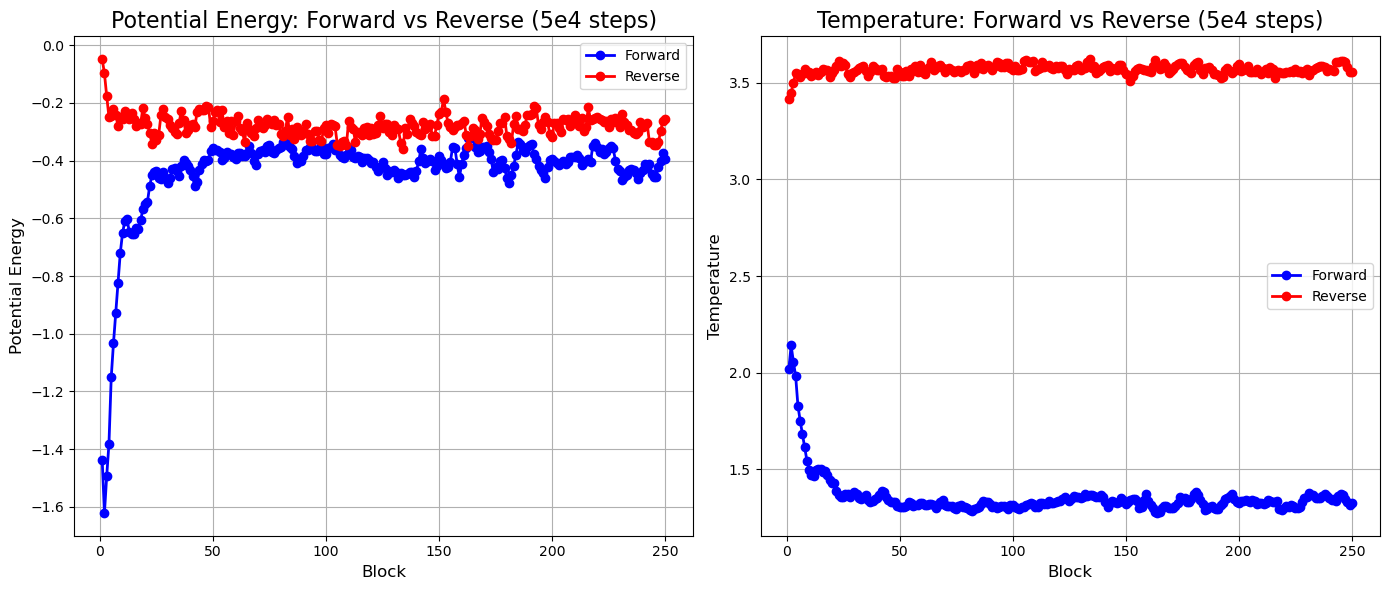

In [16]:
# Caricamento dei dati per l'energia potenziale
pot_dir_5e4 = np.loadtxt("ex04.3/OUTPUT_dir_5e4/potential_energy.dat", skiprows=1)
pot_rev_5e4 = np.loadtxt("ex04.3/OUTPUT_rev_5e4/potential_energy.dat", skiprows=1)

# Estrazione delle colonne per l'energia potenziale
blocks_dir, pot_ave_dir = pot_dir_5e4[:, 0], pot_dir_5e4[:, 1]
blocks_rev, pot_ave_rev = pot_rev_5e4[:, 0], pot_rev_5e4[:, 1]

# Caricamento dei dati per la temperatura
temp_dir_5e4 = np.loadtxt("ex04.3/OUTPUT_dir_5e4/temperature.dat", skiprows=1)
temp_rev_5e4 = np.loadtxt("ex04.3/OUTPUT_rev_5e4/temperature.dat", skiprows=1)

# Estrazione delle colonne per la temperatura
blocks_dir_temp, temp_ave_dir = temp_dir_5e4[:, 0], temp_dir_5e4[:, 1]
blocks_rev_temp, temp_ave_rev = temp_rev_5e4[:, 0], temp_rev_5e4[:, 1]

# Creazione della figura con due subplot affiancati
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Primo subplot: Energia potenziale
axes[0].errorbar(blocks_dir, pot_ave_dir, fmt="o-", label="Forward", capsize=4, color="blue")
axes[0].errorbar(blocks_rev, pot_ave_rev, fmt="o-", label="Reverse", capsize=4, color="red")
axes[0].set_xlabel("Block")
axes[0].set_ylabel("Potential Energy")
axes[0].set_title("Potential Energy: Forward vs Reverse (5e4 steps)")
axes[0].legend()
axes[0].grid(True)

# Secondo subplot: Temperatura
axes[1].errorbar(blocks_dir_temp, temp_ave_dir, fmt="o-", label="Forward", capsize=4, color="blue")
axes[1].errorbar(blocks_rev_temp, temp_ave_rev, fmt="o-", label="Reverse", capsize=4, color="red")
axes[1].set_xlabel("Block")
axes[1].set_ylabel("Temperature")
axes[1].set_title("Temperature: Forward vs Reverse (5e4 steps)")
axes[1].legend()
axes[1].grid(True)

# Layout e visualizzazione
plt.tight_layout()
plt.show()